Pre processing dei dati


In [9]:
import torch
import numpy as np
np.random.seed(1122)
torch.cuda.random.manual_seed(1122)
print(torch.cuda.is_available())

True


In [8]:
path_dataset = "../dataset/food11"
path_modelli = "../modelli"
path_logs = "../logs_food11"
device = 'cuda' if torch.cuda.is_available() else 'cpu'

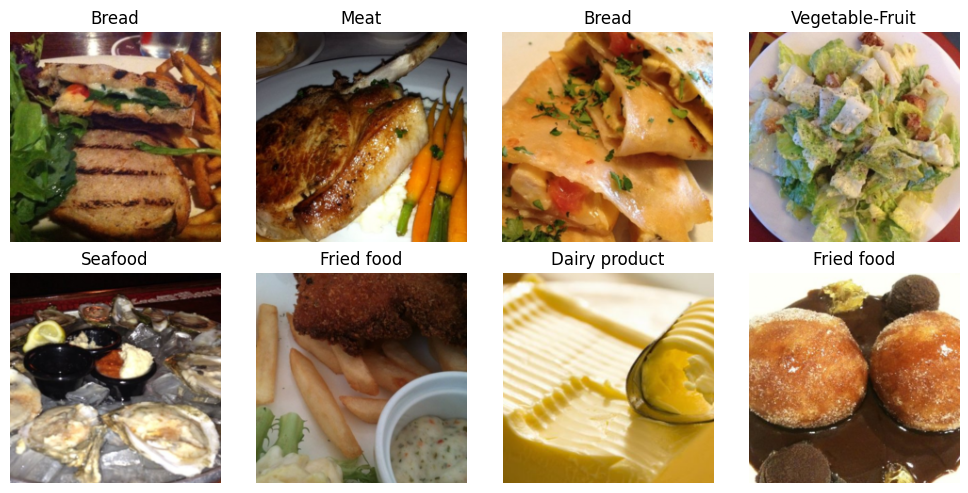

In [10]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import matplotlib.pyplot as plt

transform_train = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(
    root=os.path.join(path_dataset, "training"),
    transform = transform_train
)


train_loader = DataLoader(train_dataset, batch_size= 32, shuffle=True,num_workers=0, pin_memory=True)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.flatten()

for img, label, ax in zip(images[:8], labels[:8], axes):
    
    # Da (C, H, W) → (H, W, C)
    img = img.permute(1, 2, 0)
    ax.imshow(img)
    
    class_name = train_dataset.classes[label]
    ax.set_title(f"{class_name}")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [11]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224),      
    transforms.RandomHorizontalFlip(),    
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), 
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

transform_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])


# Creiamo i dataset per training, evaluation e validation
train_dataset = datasets.ImageFolder(
    root=os.path.join(path_dataset, "training"),
    transform=transform_train
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(path_dataset, "validation"),
    transform=transform_test
)

# da creare quando i dati di test saranno pronti
"""
test_dataset = datasets.ImageFolder(
    root=os.path.join(path_dataset, "test"),
    transform=transform_train
)
"""

class_names = train_dataset.classes
print("Classi trovate:",class_names )

# Creazione dei data loader
train_loader = DataLoader(train_dataset, batch_size= 32, shuffle=True,num_workers=2, pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size= 32, shuffle=False,num_workers= 1, pin_memory=True)

#test_loader = DataLoader(test_dataset, batch_size= 32, shuffle=False,num_workers=0,pin_memory=True)



Classi trovate: ['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 'Meat', 'Noodles-Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable-Fruit']


In [12]:
from collections import Counter

def count_images_per_class(dataset, dataset_name):
    tot = 0
    counter = Counter(dataset.targets)
    print(f"Distribuzione nel dataset {dataset_name}:")
    for class_idx, num_images in sorted(counter.items()):
        class_name = dataset.classes[class_idx]
        tot +=  num_images
        print(f" - Classe '{class_name}': {num_images} immagini")
    print(f"Totale immagini nel dataset {dataset_name} = {tot}")
    print()

# Calcola distribuzioni sui tre dataset
count_images_per_class(train_dataset, "Training")
#count_images_per_class(test_dataset, "Evaluation")
count_images_per_class(val_dataset, "Validation")

Distribuzione nel dataset Training:
 - Classe 'Bread': 1362 immagini
 - Classe 'Dairy product': 577 immagini
 - Classe 'Dessert': 2000 immagini
 - Classe 'Egg': 1321 immagini
 - Classe 'Fried food': 1135 immagini
 - Classe 'Meat': 1757 immagini
 - Classe 'Noodles-Pasta': 587 immagini
 - Classe 'Rice': 376 immagini
 - Classe 'Seafood': 1158 immagini
 - Classe 'Soup': 2000 immagini
 - Classe 'Vegetable-Fruit': 940 immagini
Totale immagini nel dataset Training = 13213

Distribuzione nel dataset Validation:
 - Classe 'Bread': 362 immagini
 - Classe 'Dairy product': 144 immagini
 - Classe 'Dessert': 500 immagini
 - Classe 'Egg': 327 immagini
 - Classe 'Fried food': 326 immagini
 - Classe 'Meat': 449 immagini
 - Classe 'Noodles-Pasta': 147 immagini
 - Classe 'Rice': 96 immagini
 - Classe 'Seafood': 347 immagini
 - Classe 'Soup': 500 immagini
 - Classe 'Vegetable-Fruit': 232 immagini
Totale immagini nel dataset Validation = 3430



In [14]:
# Salvataggio in csv (es. training)
"""
import csv

csv_path = path_dataset + "train_dataset.csv"

# Le righe hanno la struttura: [path_immagine, label, nome_classe]
with open(csv_path, mode='w', newline='') as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["image_path", "label", "class_name"])  # intestazione

    for path, label in train_dataset.samples:
        class_name = train_dataset.classes[label]
        writer.writerow([path, label, class_name])

print(f"CSV salvato in {csv_path}")
"""

'\nimport csv\n\ncsv_path = path_dataset + "train_dataset.csv"\n\n# Le righe hanno la struttura: [path_immagine, label, nome_classe]\nwith open(csv_path, mode=\'w\', newline=\'\') as csv_file:\n    writer = csv.writer(csv_file)\n    writer.writerow(["image_path", "label", "class_name"])  # intestazione\n\n    for path, label in train_dataset.samples:\n        class_name = train_dataset.classes[label]\n        writer.writerow([path, label, class_name])\n\nprint(f"CSV salvato in {csv_path}")\n'

Procedure di train, test e valutazione


In [13]:
class AverageValueMeter():
  def __init__(self):
    self.reset()

  def reset(self):
    self.sum = 0
    self.num = 0

  def add(self,value,num):
    self.sum += value*num
    self.num += num

  def value(self):
    try:
      return self.sum/self.num
    except:
      return None

In [ ]:
# procedura di training 
from torch.optim import SGD
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import accuracy_score, f1_score
from os.path import join
import torch.nn as nn


def train_classifier(model, train_loader, val_loader, exp_name = 'experiment', lr = 0.01, epochs = 10, momentum = 0.99, criterion = None, weight_decay = 0.0001, logdir = 'logs'):
  
  # funzione di loss
  if criterion is None:
    criterion = nn.CrossEntropyLoss() 
  else:
    criterion = criterion
 
  optimizer = SGD(model.parameters(), lr, momentum = momentum, weight_decay = weight_decay) # funzione di learning

  loss_meter = AverageValueMeter()
  acc_meter = AverageValueMeter()

  # writer
  writer = SummaryWriter(join(path_logs,exp_name))

  # device
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  model.to(device)

  # definiamo un dizionario contenente i loader di training e test
  loader = {
      'train': train_loader,
      'val': val_loader
  }

  # inizializziamo il global step
  global_step = 0
  
  # inizializzaimo la best acc e la corrispondente epoca
  best_acc = 0
  best_epoch = 0

  for e in range(epochs):
    print(f"Epoch: {e+1} of {epochs}")
    # iteriamo tra due modalità: train e test
    for mode in ['train','val']:
      loss_meter.reset()
      acc_meter.reset()
      model.train() if mode == 'train' else model.eval()

      # per macro f1 score
      all_preds = []
      all_labels = []

      with torch.set_grad_enabled(mode == 'train'): # abilitiamo i gradienti in training
        for i, batch in enumerate(loader[mode]):
          x = batch[0].to(device) #portiamoli sul device corretto
          y = batch[1].to(device)
          output = model(x)

          # aggiorniamo il global_step
          # conterrà il numero di campioni visti durante il training
          n = x.shape[0]
          global_step += n
          l = criterion(output,y)

          if mode == 'train':
            l.backward()
            optimizer.step()
            optimizer.zero_grad()

          # parte per macro f1 score
          preds = output.max(1)[1].cpu()
          labels = y.cpu()

          all_preds.extend(preds.numpy())
          all_labels.extend(labels.numpy())

          acc = accuracy_score(y.to('cpu'),output.to('cpu').max(1)[1])
          loss_meter.add(l.item(),n)
          acc_meter.add(acc,n)

          # loggiamo i risultati iterazione per iterazione solo durante il training
          if mode == 'train':
            writer.add_scalar('loss/train', loss_meter.value(), global_step = global_step)
            writer.add_scalar('accuracy/train', acc_meter.value(), global_step = global_step)


      # Calcolo macro F1 a fine epoca
      macro_f1 = f1_score(all_labels, all_preds, average='macro')


      # una volta finita l'epoca (sia nel caso di training che test, loggiamo le stime finali)
      acc = acc_meter.value()
      writer.add_scalar('loss/'+mode, loss_meter.value(), global_step = global_step)
      writer.add_scalar('accuracy/'+mode, acc, global_step = global_step)
      writer.add_scalar(f'macro_f1/{mode}', macro_f1, global_step=global_step)

      # best accuracy
      if mode == 'val' and acc > best_acc:
        best_acc = acc
        best_epoch = e + 1
        print(f"Miglioramento sul val: accuracy  = {best_acc} all'epoca {best_epoch}")
        # conserviamo i pesi quando miglioriamo
        #os.makedirs(path_modelli + "/%s" %(exp_name), exist_ok=True)
        #torch.save(model.state_dict(),path_modelli + '/%s/%s-%d.pth' % (exp_name,exp_name,e+1))
      
      # conserviamo i pesi del modello alla fine di ogni epoca
      os.makedirs(path_modelli + "/%s" %(exp_name), exist_ok=True)
      torch.save(model.state_dict(),path_modelli + '/%s/%s-%d.pth' % (exp_name,exp_name,e+1))
  #torch.save(model.state_dict(), path_modelli + f"{exp_name}-{e+1}.pth")

  return model

In [16]:
# funzione per ottenere le predizione del modello
def test_classifier(model, loader):
  device = "cuda" if torch.cuda.is_available() else "cpu"
  model.to(device)
  predictions, labels = [],[]
  for batch in loader:
    x = batch[0].to(device)
    y = batch[1].to(device)
    output = model(x)
    preds = output.to("cpu").max(1)[1].numpy() # le funzioni numpy girano solo su cpu
    labs = y.to("cpu").numpy()
    predictions.extend(list(preds))
    labels.extend(list(labs))
  return np.array(predictions), np.array(labels)

In [17]:
# stampa della matrice di confusione
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm,class_names):
    plt.figure(figsize=(12,8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.colorbar()

    n_classes = cm.shape[0]
    if class_names is not None:
        ticks = np.arange(n_classes)
        plt.xticks(ticks, class_names, rotation=45, ha='right')
        plt.yticks(ticks, class_names)
    else:
        plt.xlabel('Predicted label')
        plt.ylabel('True label')

    plt.tight_layout()
    plt.show()


In [18]:
from sklearn.metrics import (classification_report,confusion_matrix)

def evaluate_classifier(y_pred, y_true, class_names=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    print("=== Classification Report ===")
    print(report)
    plot_confusion_matrix(cm_norm,class_names)
    return report,cm


Squeezenet



In [19]:
# Funzione che adatta il modello squeezenet al mio specifico task

from torch import nn
from torchvision.models import squeezenet1_0
from torchvision.models import SqueezeNet1_0_Weights

def get_squeezenet_model(num_class):
  model = squeezenet1_0(weights = SqueezeNet1_0_Weights)
  model.classifier[1] = nn.Conv2d(512,num_class,kernel_size = (1,1), stride = (1,1))
  model.num_classes = num_class
  return model

squeezenet = get_squeezenet_model(11)

c:\Users\giova\Documents\Università\Machine learning\machine_learning\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_0_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [20]:
# Funzione che congela i layer del blocco feature e mantiene solo il blocco classifier

def freeze_features(model):

    for param in model.parameters():
        param.requires_grad = False
    
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model

In [21]:
# Funzione che sblocca tutti i layer -> allenare tutto il modello

def unfreeze_all_layers(model):
    
    for param in model.parameters():
        param.requires_grad = True
    
    return model

In [22]:
# Funzione per stampare quali layer sono bloccati e quali sono allenabili 

def print_trainable_layers(model):
    
    for name, param in model.named_parameters():
        status = "Trainable" if param.requires_grad else "Frozen"
        print(f"{name}: {status}")


In [25]:
def test_squeezenet_with_frozen_features(train_loader,val_loader,exp_name = "experiment",epochs = 30,lr = 0.0001, weight_decay = 0.0001, criterion = None):
    model = get_squeezenet_model(11)
    model = freeze_features(model)
    # print_trainable_layers(model)
    model = train_classifier(model, train_loader, val_loader, exp_name= exp_name, epochs= epochs, lr= lr, logdir = path_logs, weight_decay = weight_decay, criterion = criterion)
    
    y_pred, y_true = test_classifier(model, val_loader)
    evaluate_classifier(y_pred, y_true, class_names)


In [26]:
def test_squeezenet_with_all_layers_trainable(train_loader,val_loader,exp_name = "experiment",epochs = 30,lr = 0.0001, weight_decay = 0.0001, criterion = None):
    model = get_squeezenet_model(11)
    model = unfreeze_all_layers(model)
    # print_trainable_layers(model)
    model = train_classifier(model, train_loader, val_loader, exp_name= exp_name, epochs= epochs, lr= lr, logdir = path_logs, weight_decay = weight_decay, criterion = criterion)
    
    y_pred, y_true = test_classifier(model, val_loader)
    evaluate_classifier(y_pred, y_true, class_names)

Training e valutazione su squeezenet con layer di estrazione delle features congelati

In [31]:
# lr = 0.001
# test_squeezenet_with_frozen_features(train_loader, val_loader, exp_name = "squeezenet_frozen_features_lr=0.001", epochs = 30, lr=0.001)

# lr = 0.0001
# test_squeezenet_with_frozen_features(train_loader, val_loader, exp_name = "squeezenet_frozen_features_lr=0.0001", epochs = 30, lr=0.0001)


Training e valutazione su squeezenet con tutti i layer allenabili


c:\Users\giova\Documents\Università\Machine learning\machine_learning\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_0_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


=== Classification Report ===
                 precision    recall  f1-score   support

          Bread       0.76      0.67      0.71       362
  Dairy product       0.73      0.71      0.72       144
        Dessert       0.81      0.66      0.72       500
            Egg       0.63      0.80      0.71       327
     Fried food       0.77      0.75      0.76       326
           Meat       0.78      0.81      0.79       449
  Noodles-Pasta       0.90      0.95      0.93       147
           Rice       0.78      0.95      0.85        96
        Seafood       0.84      0.82      0.83       347
           Soup       0.88      0.94      0.91       500
Vegetable-Fruit       0.89      0.85      0.87       232

       accuracy                           0.79      3430
      macro avg       0.80      0.81      0.80      3430
   weighted avg       0.80      0.79      0.79      3430



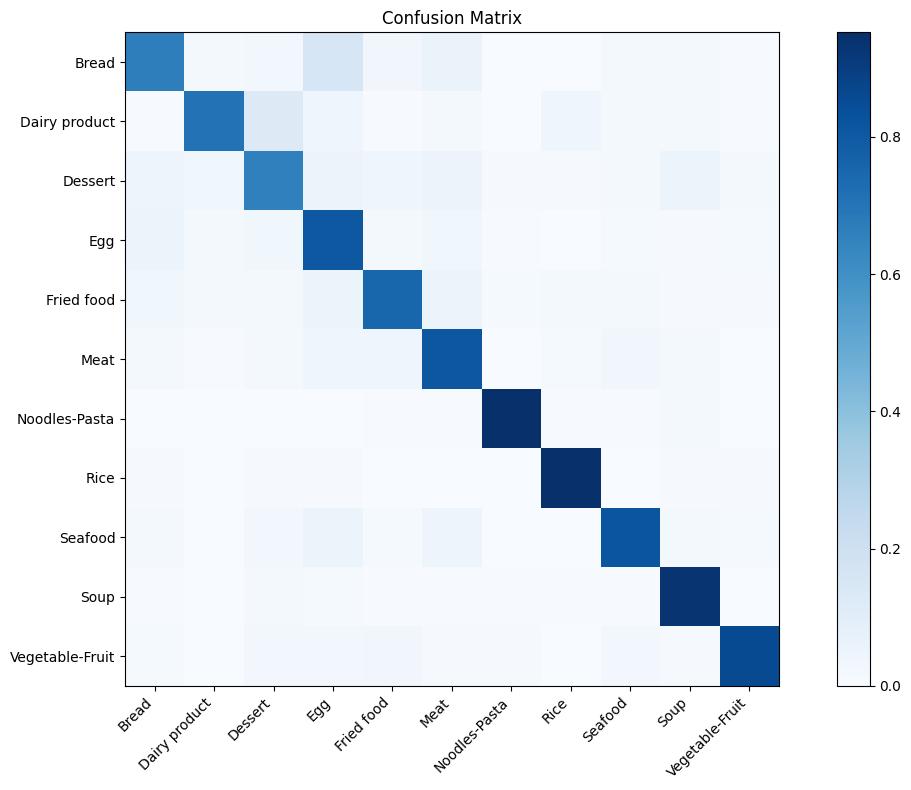

('                 precision    recall  f1-score   support\n\n          Bread       0.76      0.67      0.71       362\n  Dairy product       0.73      0.71      0.72       144\n        Dessert       0.81      0.66      0.72       500\n            Egg       0.63      0.80      0.71       327\n     Fried food       0.77      0.75      0.76       326\n           Meat       0.78      0.81      0.79       449\n  Noodles-Pasta       0.90      0.95      0.93       147\n           Rice       0.78      0.95      0.85        96\n        Seafood       0.84      0.82      0.83       347\n           Soup       0.88      0.94      0.91       500\nVegetable-Fruit       0.89      0.85      0.87       232\n\n       accuracy                           0.79      3430\n      macro avg       0.80      0.81      0.80      3430\n   weighted avg       0.80      0.79      0.79      3430\n',
 array([[241,   8,   9,  56,  11,  22,   0,   0,   7,   6,   2],
        [  1, 102,  18,   6,   1,   3,   0,   6,   3,   

: 

: 

: 

: 

: 

In [ ]:
# lr = 0.01
# test_squeezenet_with_all_layers_trainable(train_loader, val_loader, exp_name = "squeezenet_all_layers_trainable_lr=0.01", epochs = 30, lr=0.01)

# lr = 0.001
# test_squeezenet_with_all_layers_trainable(train_loader, val_loader, exp_name = "squeezenet_all_layers_trainable_lr=0.001", epochs = 30, lr=0.001)

# lr = 0.0001
# test_squeezenet_with_all_layers_trainable(train_loader, val_loader, exp_name = "squeezenet_all_layers_trainable_lr=0.0001", epochs = 30, lr=0.0001)

# lr = 0.0001 e weight decay = 0.00001
# test_squeezenet_with_all_layers_trainable(train_loader, val_loader, exp_name = "squeezenet_all_layers_trainable_lr=0.0001_weightDecay=0.00001", epochs = 30, lr=0.0001, weight_decay=0.00001)


# lr = 0.0001 con weighted loss (bread, dairy product, dessert)
"""
weights = torch.ones(11).cuda()
weights[1] = 2.0
weights[0] = 1.5
weights[2] = 1.5
criterion = nn.CrossEntropyLoss(weight=weights)
test_squeezenet_with_all_layers_trainable(train_loader, val_loader, exp_name = "squeezenet_all_layers_trainable_lr=0.0001_weighted loss", epochs = 30, lr=0.0001, criterion = criterion)
"""



Resnet

In [27]:
# funzione che adatta il modello resnet al mio specifico task
from torchvision.models import resnet18
from torchvision.models import ResNet18_Weights 

def get_resnet_model():
    model = resnet18(weights = ResNet18_Weights.DEFAULT)
    num_classes = 11
    model.fc = nn.Linear(512, num_classes)
    model.num_classes = num_classes
    return model

In [28]:
# Funzione che congela i layer del blocco feature e mantiene solo il blocco fc

def freeze_resnet_features(model):

    for param in model.parameters():
        param.requires_grad = False
    
    for param in model.fc.parameters():
        param.requires_grad = True

    return model

In [ ]:
def test_resnet_with_all_layers_trainable(train_loader,val_loader,exp_name = "experiment",epochs = 30,lr = 0.0001, weight_decay = 0.0001, criterion = None):
    model = get_resnet_model()
    model = unfreeze_all_layers(model)
    # print_trainable_layers(model)
    model = train_classifier(model, train_loader, val_loader, exp_name= exp_name, epochs= epochs, lr= lr, logdir = path_logs, weight_decay = weight_decay, criterion = criterion)
    
    y_pred, y_true = test_classifier(model, val_loader)
    evaluate_classifier(y_pred, y_true, class_names)

In [30]:
def test_resnet_with_frozen_features(train_loader,val_loader,exp_name = "experiment",epochs = 30,lr = 0.0001, weight_decay = 0.0001, criterion = None):
    model = get_resnet_model()
    model = freeze_resnet_features(model)
    # print_trainable_layers(model)
    model = train_classifier(model, train_loader, val_loader, exp_name= exp_name, epochs= epochs, lr= lr, logdir = path_logs, weight_decay = weight_decay, criterion = criterion)
    
    y_pred, y_true = test_classifier(model, val_loader)
    evaluate_classifier(y_pred, y_true, class_names)


Training e valutazione su resnet con layer di estrazione delle features congelati

In [ ]:
 # test_resnet_with_frozen_features(train_loader,val_loader,"resnet_frozen_features_lr=0.0001",30,lr = 0.0001)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\giova/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Epoch: 1 of 30


KeyboardInterrupt: 

: 

: 

: 

: 

: 